# EDA — Dataset 2 (Emergency Vehicle Sirens with Traffic Noise)

Dataset **produksi**: 4 kelas (`ambulance`, `firetruck`, `police`, `traffic`), sirine sudah di-overlay
dengan noise lalu lintas sehingga lebih mendekati kondisi nyata.

Ini dataset yang dipakai untuk melatih model yang di-deploy.

## Yang dicari di notebook ini

1. Integritas & konsistensi format (sama seperti D1)
2. **Struktur penamaan file → risiko data leakage** ← bagian terpenting
3. Keseimbangan kelas
4. Karakter akustik, khususnya seberapa mirip `police` vs `ambulance` vs `firetruck`

## Struktur folder

```
Dataset/Dataset2/
├── Dataset/Dataset/
│   ├── ambulance/   mixed_sound_1.wav, mixed_sound_1_1.wav, ...
│   ├── firetruck/
│   └── police/
└── traffic/traffic/  sound_401.wav, ...
```

Perhatikan penamaan kelas sirine: ada `mixed_sound_N.wav` **dan** `mixed_sound_N_1.wav`.
Bagian 3 menyelidiki apa artinya — dan kenapa itu menentukan cara split data.

In [1]:
import hashlib
import re
import wave
import warnings
from pathlib import Path

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# ------------------------------------------------------------------ config
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
D2_ROOT = ROOT / "Dataset" / "Dataset2"
FIG_DIR = ROOT / "figures" / "eda_d2"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# tiap kelas punya lokasi sendiri — traffic terpisah dari sirine
CLASS_DIRS = {
    "ambulance": D2_ROOT / "Dataset" / "Dataset" / "ambulance",
    "firetruck": D2_ROOT / "Dataset" / "Dataset" / "firetruck",
    "police":    D2_ROOT / "Dataset" / "Dataset" / "police",
    "traffic":   D2_ROOT / "traffic" / "traffic",
}
CLASSES = list(CLASS_DIRS)
PALETTE = dict(zip(CLASSES, sns.color_palette("Set2", len(CLASSES))))

SR = 22050
DURATION = 3.0
N_FFT, HOP, N_MELS = 1024, 512, 64

for cls, d in CLASS_DIRS.items():
    assert d.exists(), f"folder {cls} tidak ditemukan: {d}"
print("semua folder kelas ditemukan")
print(f"figures : {FIG_DIR}")

semua folder kelas ditemukan
figures : d:\Coding Vscode\Siren Classification\figures\eda_d2


d:\Coding Vscode\Siren Classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 1 · Inventaris file

In [2]:
def read_wav_header(path: Path) -> dict:
    """Metadata WAV tanpa decode audio."""
    try:
        with wave.open(str(path), "rb") as w:
            n_frames, sr = w.getnframes(), w.getframerate()
            return {"sample_rate": sr, "channels": w.getnchannels(),
                    "bit_depth": w.getsampwidth() * 8, "n_frames": n_frames,
                    "duration": n_frames / sr if sr else 0.0, "readable": True}
    except Exception as e:
        return {"sample_rate": None, "channels": None, "bit_depth": None,
                "n_frames": None, "duration": None, "readable": False,
                "error": str(e)}


def build_inventory(class_dirs: dict) -> pd.DataFrame:
    rows = []
    for label, folder in class_dirs.items():
        for f in tqdm(sorted(folder.glob("*.wav")), desc=label, leave=False):
            row = {"filename": f.name, "stem": f.stem, "label": label,
                   "path": str(f),
                   "size_kb": round(f.stat().st_size / 1024, 1),
                   "md5": hashlib.md5(f.read_bytes()).hexdigest()}
            row.update(read_wav_header(f))
            rows.append(row)
    return pd.DataFrame(rows)


df = build_inventory(CLASS_DIRS)
print(f"total file .wav : {len(df)}")
df.head()


ambulance:   0%|          | 0/400 [00:00<?, ?it/s]


ambulance:  26%|██▌       | 102/400 [00:00<00:00, 1015.11it/s]


ambulance:  52%|█████▏    | 206/400 [00:00<00:00, 1025.57it/s]


ambulance:  78%|███████▊  | 310/400 [00:00<00:00, 1029.95it/s]


firetruck:   0%|          | 0/400 [00:00<?, ?it/s]

...


traffic:  45%|████▌     | 190/421 [00:00<00:00, 959.85it/s]


traffic:  69%|██████▉   | 292/421 [00:00<00:00, 983.53it/s]


traffic:  93%|█████████▎| 393/421 [00:00<00:00, 991.51it/s]

total file .wav : 1675


,filename,stem,label,path,size_kb,md5,sample_rate,channels,bit_depth,n_frames,duration,readable
0,mixed_sound_1.wav,mixed_sound_1,ambulance,d:\Coding Vscode\Siren Classification\Dataset\...,516.8,6f5302ea3a07ca704aeb9e17f67fa3f0,44100,2,16,132300,3.0,True
1,mixed_sound_10.wav,mixed_sound_10,ambulance,d:\Coding Vscode\Siren Classification\Dataset\...,516.8,5b12062876f4d298ee0f9a0fbda188d1,44100,2,16,132300,3.0,True
2,mixed_sound_100.wav,mixed_sound_100,ambulance,d:\Coding Vscode\Siren Classification\Dataset\...,516.8,f172dd145c771d664238f600e607a435,44100,2,16,132300,3.0,True
3,mixed_sound_100_1.wav,mixed_sound_100_1,ambulance,d:\Coding Vscode\Siren Classification\Dataset\...,516.8,81b989f38734e7231a39b04a087ff6ef,44100,2,16,132300,3.0,True
4,mixed_sound_101.wav,mixed_sound_101,ambulance,d:\Coding Vscode\Siren Classification\Dataset\...,516.8,cc3cb9f204bbb24f46e1e58854817b2b,44100,2,16,132300,3.0,True


---
## 2 · Integritas & konsistensi format

In [3]:
corrupt = df[~df.readable]
n_dup = int(df.md5.duplicated().sum())
print(f"file tidak terbaca : {len(corrupt)}")
print(f"file duplikat      : {n_dup}")

print("\n— sample rate —")
print(pd.crosstab(df.label, df.sample_rate, margins=True, margins_name="TOTAL"))
print("\n— channel (1=mono, 2=stereo) —")
print(pd.crosstab(df.label, df.channels, margins=True, margins_name="TOTAL"))
print("\n— durasi —")
print(df.groupby("label").duration.describe()[["min", "50%", "max"]].round(3))

file tidak terbaca : 0
file duplikat      : 0

— sample rate —
sample_rate  44100  TOTAL
label                    
ambulance      400    400
firetruck      400    400
police         454    454
traffic        421    421
TOTAL         1675   1675

— channel (1=mono, 2=stereo) —
channels      2  TOTAL
label                 
ambulance   400    400
firetruck   400    400
police      454    454
traffic     421    421
TOTAL      1675   1675

— durasi —
           min  50%    max
label                     
ambulance  3.0  3.0  3.019
firetruck  3.0  3.0  3.008
police     3.0  3.0  3.000
traffic    3.0  3.0  3.000


---
## 3 · Struktur penamaan → risiko data leakage

> **Bagian paling penting di notebook ini.**

Dataset ini dibuat dengan cara *mencampur* rekaman sirine dengan noise lalu lintas.
Kalau satu rekaman sirine dipakai beberapa kali dengan noise berbeda, hasilnya adalah
beberapa file yang **berbeda secara byte tapi berasal dari sumber yang sama**.

Kalau file-file bersaudara itu tersebar ke train dan test, model bisa "mengenali" rekaman
yang sudah pernah dilihatnya — akurasi test jadi tinggi palsu, dan angkanya tidak akan
bertahan di dunia nyata.

Deteksi hash isi file tidak akan menangkap ini (noise-nya beda → hash beda).
Satu-satunya petunjuk ada di **pola nama file**.

In [4]:
# --- 3a. pola nama apa saja yang ada? angka diganti '#' biar polanya kelihatan ---
df["name_pattern"] = df.stem.str.replace(r"\d+", "#", regex=True)
print(pd.crosstab(df.label, df.name_pattern, margins=True, margins_name="TOTAL"))

name_pattern  mixed_sound_#  mixed_sound_#_#  sound_#  TOTAL
label                                                       
ambulance               200              200        0    400
firetruck               200              200        0    400
police                  227              227        0    454
traffic                   0                0      421    421
TOTAL                   627              627      421   1675


In [5]:
# --- 3b. tarik source_id dari nama file ---
#
# mixed_sound_57.wav   -> id 57  \  varian dari rekaman sirine yang sama
# mixed_sound_57_1.wav -> id 57  /
# sound_401.wav        -> id 401 (traffic, tidak berpasangan)
#
# Prefix kelas itu wajib: penomoran diulang di tiap kelas, jadi tanpa prefix
# ambulance_57 dan firetruck_57 akan dianggap satu grup yang sama.

def parse_source_id(stem: str, label: str) -> str:
    match = re.search(r"(\d+)", stem)
    base = match.group(1) if match else stem
    return f"{label}_{base}"


df["source_id"] = [parse_source_id(s, l) for s, l in zip(df.stem, df.label)]

group_stats = df.groupby("label").agg(
    n_files=("filename", "size"),
    n_sources=("source_id", "nunique"),
)
group_stats["file_per_source"] = (
    group_stats.n_files / group_stats.n_sources).round(2)
group_stats

,n_files,n_sources,file_per_source
label,,,
ambulance,400,200,2.0
firetruck,400,200,2.0
police,454,227,2.0
traffic,421,421,1.0


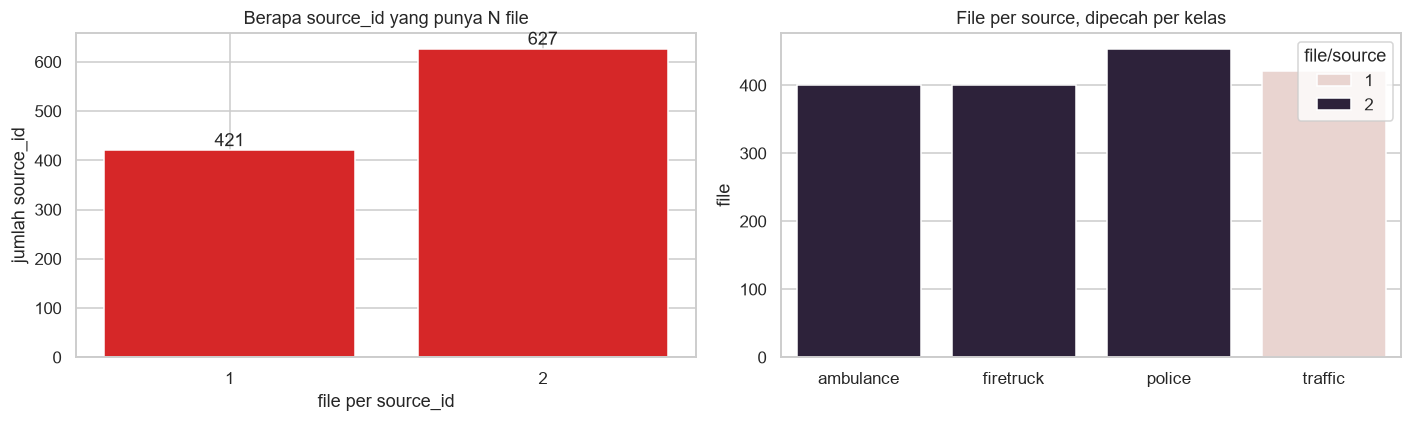

total file        : 1675
total source unik : 1048
rata-rata         : 1.60 file per source


In [6]:
# --- 3c. berapa file per source_id? ---
files_per_source = df.groupby("source_id").size()
dist = files_per_source.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(dist.index.astype(str), dist.values, color="tab:red")
axes[0].set(title="Berapa source_id yang punya N file",
            xlabel="file per source_id", ylabel="jumlah source_id")
for i, v in enumerate(dist.values):
    axes[0].text(i, v, str(v), ha="center", va="bottom")

sns.countplot(data=df.assign(n=df.source_id.map(files_per_source)),
              x="label", hue="n", order=CLASSES, ax=axes[1])
axes[1].set(title="File per source, dipecah per kelas", xlabel="", ylabel="file")
axes[1].legend(title="file/source")

plt.tight_layout()
plt.savefig(FIG_DIR / "source_grouping.png", bbox_inches="tight")
plt.show()

print(f"total file        : {len(df)}")
print(f"total source unik : {df.source_id.nunique()}")
print(f"rata-rata         : {len(df) / df.source_id.nunique():.2f} file per source")

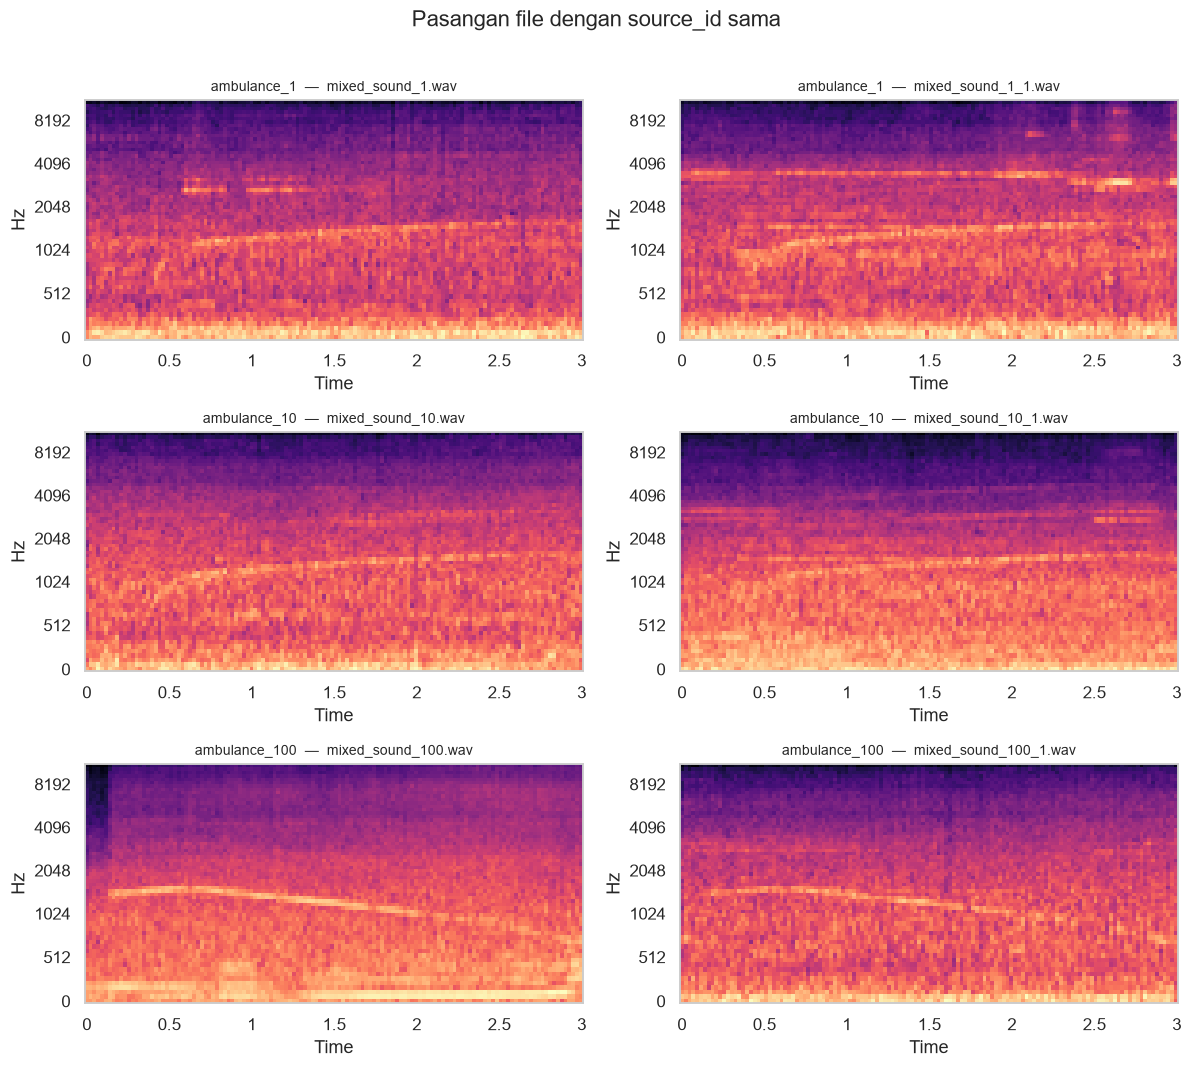

Kalau tiap baris terlihat mirip kiri-kanan → konfirmasi: satu sumber, dua overlay.
→ Split WAJIB group-aware (GroupShuffleSplit by source_id), bukan random.


In [7]:
# --- 3d. buktikan: dua file sesaudara memang mirip? ---
# Bandingkan sepasang file dengan source_id sama. Kalau benar berasal dari
# rekaman sirine yang sama, pola harmoniknya akan tampak serupa meski
# lapisan noise-nya berbeda.

def load_audio(path: str) -> np.ndarray:
    y, _ = librosa.load(path, sr=SR, mono=True, duration=DURATION)
    peak = np.abs(y).max()
    return y / peak if peak > 0 else y


def logmel(y: np.ndarray) -> np.ndarray:
    mel = librosa.feature.melspectrogram(
        y=y, sr=SR, n_fft=N_FFT, hop_length=HOP, n_mels=N_MELS, power=2.0)
    return librosa.power_to_db(mel, ref=np.max)


paired = files_per_source[files_per_source > 1].index[:3]
fig, axes = plt.subplots(len(paired), 2, figsize=(11, 3.2 * len(paired)))
for r, sid in enumerate(paired):
    members = df[df.source_id == sid]
    for c, (_, rec) in enumerate(members.head(2).iterrows()):
        librosa.display.specshow(logmel(load_audio(rec.path)), sr=SR,
                                 hop_length=HOP, x_axis="time", y_axis="mel",
                                 ax=axes[r, c])
        axes[r, c].set_title(f"{sid}  —  {rec.filename}", fontsize=9)
plt.suptitle("Pasangan file dengan source_id sama", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "paired_sources.png", bbox_inches="tight")
plt.show()

print("Kalau tiap baris terlihat mirip kiri-kanan → konfirmasi: satu sumber, dua overlay.")
print("→ Split WAJIB group-aware (GroupShuffleSplit by source_id), bukan random.")

In [8]:
# --- 3e. seberapa besar dampaknya? simulasi random split vs group split ---
from sklearn.model_selection import GroupShuffleSplit, train_test_split

TEST_SIZE, SEED = 0.15, 42

# (a) random split — cara yang salah
idx_tr, idx_te = train_test_split(
    np.arange(len(df)), test_size=TEST_SIZE, random_state=SEED,
    stratify=df.label)
leak_random = len(set(df.source_id.iloc[idx_tr]) & set(df.source_id.iloc[idx_te]))

# (b) group split — cara yang benar
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=SEED)
g_tr, g_te = next(gss.split(df, groups=df.source_id))
leak_group = len(set(df.source_id.iloc[g_tr]) & set(df.source_id.iloc[g_te]))

print(f"Random split  → {leak_random:3d} source bocor ke train & test")
print(f"Group split   → {leak_group:3d} source bocor")

n_leaked_files = int(df.iloc[idx_te].source_id.isin(
    set(df.source_id.iloc[idx_tr])).sum())
print(f"\nDengan random split, {n_leaked_files} dari {len(idx_te)} file test "
      f"({n_leaked_files / len(idx_te):.0%}) punya saudara di train.")
print("Itulah besar inflasi akurasi yang dihindari oleh group split.")

Random split  → 164 source bocor ke train & test
Group split   →   0 source bocor

Dengan random split, 164 dari 252 file test (65%) punya saudara di train.
Itulah besar inflasi akurasi yang dihindari oleh group split.


---
## 4 · Distribusi kelas

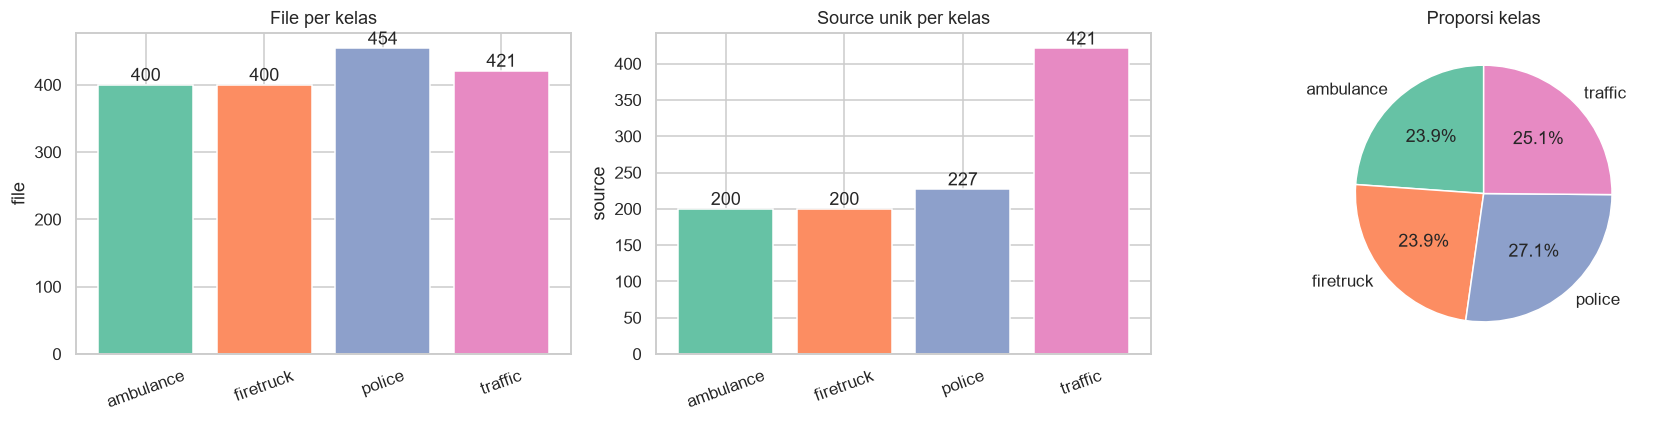

rasio file  (max/min) = 1.14
rasio source(max/min) = 2.10

Catatan: rasio source lebih relevan dari rasio file — traffic punya
banyak source tapi tanpa pasangan, sirine sebaliknya.


In [9]:
counts = df.label.value_counts().reindex(CLASSES)
src_counts = df.groupby("label").source_id.nunique().reindex(CLASSES)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].bar(counts.index, counts.values, color=[PALETTE[c] for c in counts.index])
axes[0].set(title="File per kelas", ylabel="file")
for i, v in enumerate(counts.values):
    axes[0].text(i, v, str(v), ha="center", va="bottom")

axes[1].bar(src_counts.index, src_counts.values,
            color=[PALETTE[c] for c in src_counts.index])
axes[1].set(title="Source unik per kelas", ylabel="source")
for i, v in enumerate(src_counts.values):
    axes[1].text(i, v, str(v), ha="center", va="bottom")

axes[2].pie(counts.values, labels=counts.index, autopct="%1.1f%%",
            colors=[PALETTE[c] for c in counts.index], startangle=90)
axes[2].set_title("Proporsi kelas")

for ax in axes[:2]:
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(FIG_DIR / "class_distribution.png", bbox_inches="tight")
plt.show()

print(f"rasio file  (max/min) = {counts.max() / counts.min():.2f}")
print(f"rasio source(max/min) = {src_counts.max() / src_counts.min():.2f}")
print("\nCatatan: rasio source lebih relevan dari rasio file — traffic punya")
print("banyak source tapi tanpa pasangan, sirine sebaliknya.")

---
## 5 · Bentuk sinyal per kelas

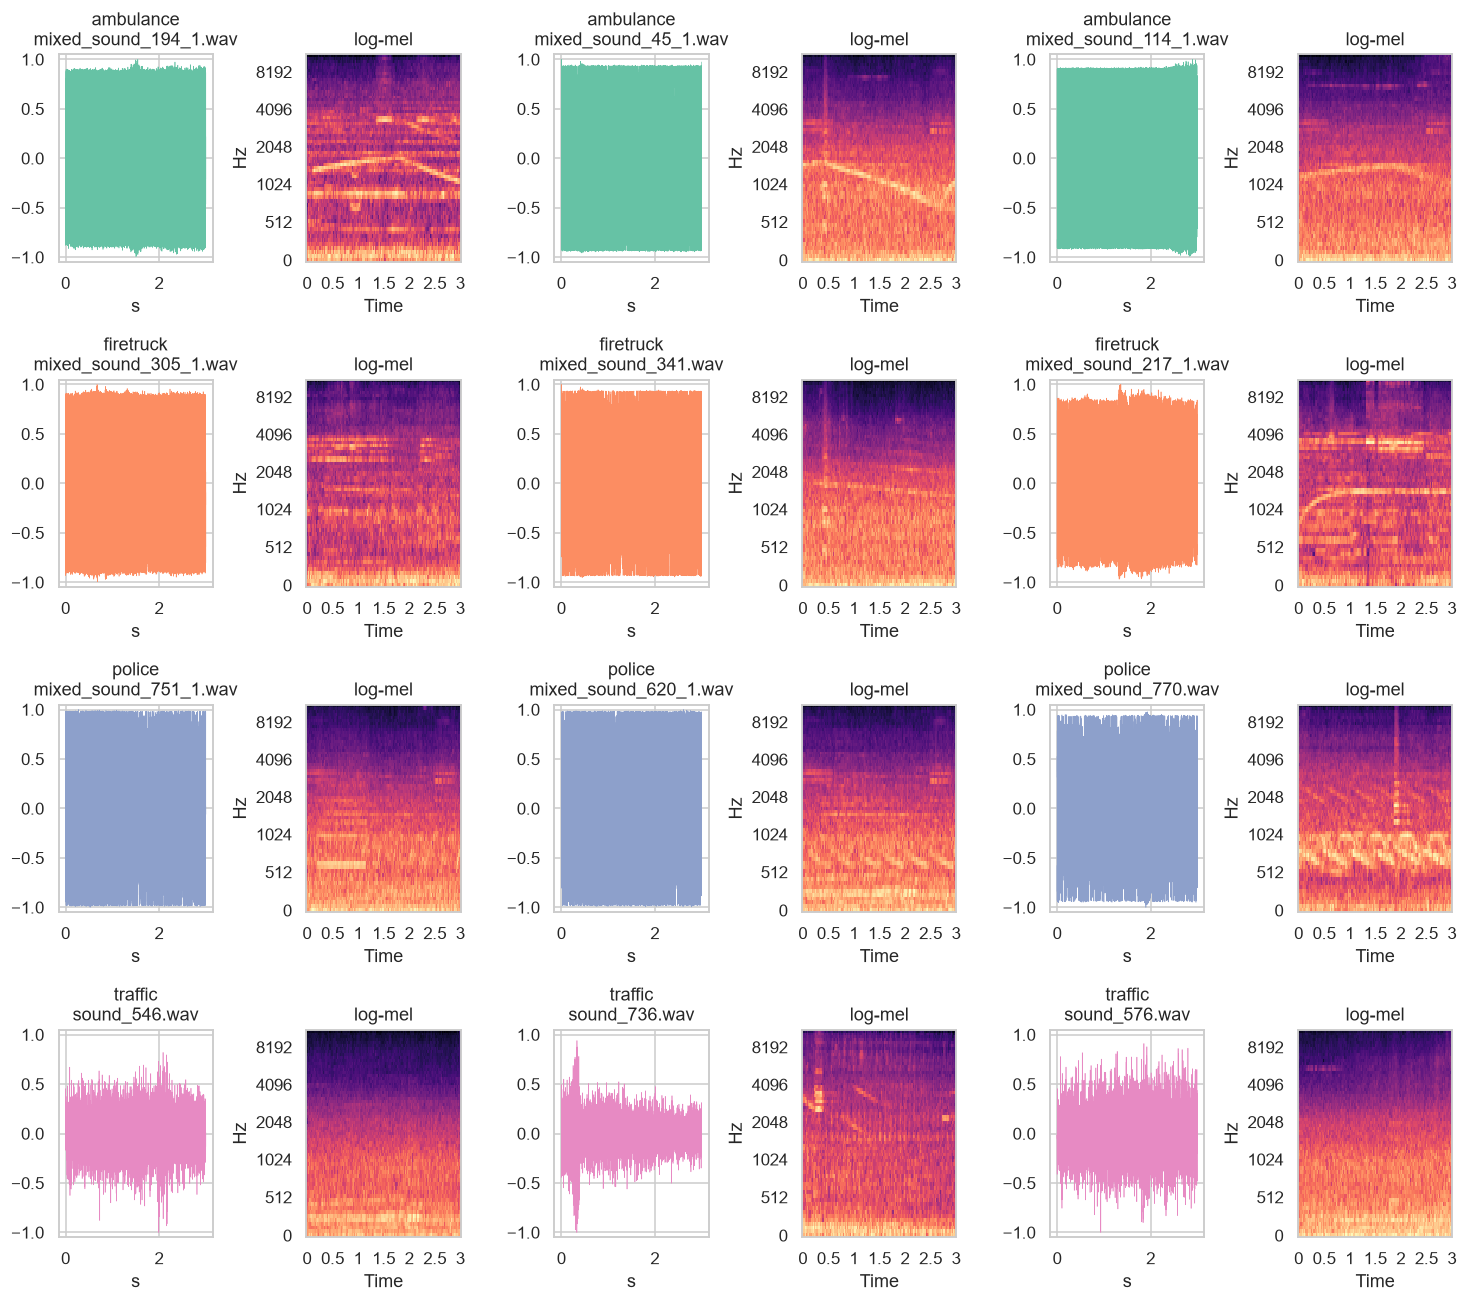

In [10]:
N_EXAMPLES = 3

fig, axes = plt.subplots(len(CLASSES), N_EXAMPLES * 2,
                         figsize=(4.5 * N_EXAMPLES, 3 * len(CLASSES)))
for r, cls in enumerate(CLASSES):
    picks = df[df.label == cls].sample(N_EXAMPLES, random_state=42)
    for c, (_, rec) in enumerate(picks.iterrows()):
        y = load_audio(rec.path)
        ax_w, ax_s = axes[r, c * 2], axes[r, c * 2 + 1]
        ax_w.plot(np.linspace(0, len(y) / SR, len(y)), y,
                  lw=0.4, color=PALETTE[cls])
        ax_w.set(ylim=(-1.05, 1.05), title=f"{cls}\n{rec.filename}",
                 xlabel="s")
        librosa.display.specshow(logmel(y), sr=SR, hop_length=HOP,
                                 x_axis="time", y_axis="mel", ax=ax_s)
        ax_s.set_title("log-mel")
plt.tight_layout()
plt.savefig(FIG_DIR / "waveform_spectrogram.png", bbox_inches="tight")
plt.show()

---
## 6 · Ciri akustik per kelas

Pertanyaan kunci di sini: **seberapa terpisah ketiga jenis sirine?**
Traffic hampir pasti mudah dibedakan. Yang menantang adalah ambulance vs firetruck vs police —
kalau distribusinya tumpang tindih, harapkan confusion di antara mereka saat evaluasi model.

In [11]:
def acoustic_features(path: str) -> pd.Series:
    y = load_audio(path)
    return pd.Series({
        "rms": float(librosa.feature.rms(y=y).mean()),
        "zcr": float(librosa.feature.zero_crossing_rate(y).mean()),
        "centroid": float(librosa.feature.spectral_centroid(y=y, sr=SR).mean()),
        "bandwidth": float(librosa.feature.spectral_bandwidth(y=y, sr=SR).mean()),
    })


tqdm.pandas(desc="ekstrak fitur")
df = pd.concat([df, df.path.progress_apply(acoustic_features)], axis=1)

df.groupby("label")[["rms", "zcr", "centroid", "bandwidth"]].agg(["mean", "std"]).round(3)


ekstrak fitur:   0%|          | 0/1675 [00:00<?, ?it/s]


ekstrak fitur:   0%|          | 8/1675 [00:00<00:22, 75.03it/s]


ekstrak fitur:   1%|          | 16/1675 [00:00<00:23, 69.70it/s]


ekstrak fitur:   1%|▏         | 23/1675 [00:00<00:24, 68.73it/s]


ekstrak fitur:   2%|▏         | 30/1675 [00:00<00:24, 67.56it/s]

...


ekstrak fitur:  99%|█████████▉| 1655/1675 [00:24<00:00, 68.74it/s]


ekstrak fitur:  99%|█████████▉| 1663/1675 [00:24<00:00, 69.21it/s]


ekstrak fitur: 100%|█████████▉| 1671/1675 [00:24<00:00, 69.17it/s]


ekstrak fitur: 100%|██████████| 1675/1675 [00:24<00:00, 67.57it/s]

rms           zcr         centroid          bandwidth         
            mean    std   mean    std      mean      std      mean      std
label                                                                      
ambulance  0.544  0.063  0.094  0.038  1836.555  536.512  2004.424  353.770
firetruck  0.523  0.070  0.100  0.041  1987.755  494.528  2134.029  296.190
police     0.540  0.064  0.090  0.041  1806.318  546.038  1992.055  373.094
traffic    0.211  0.038  0.086  0.048  1687.635  641.244  1912.378  463.003

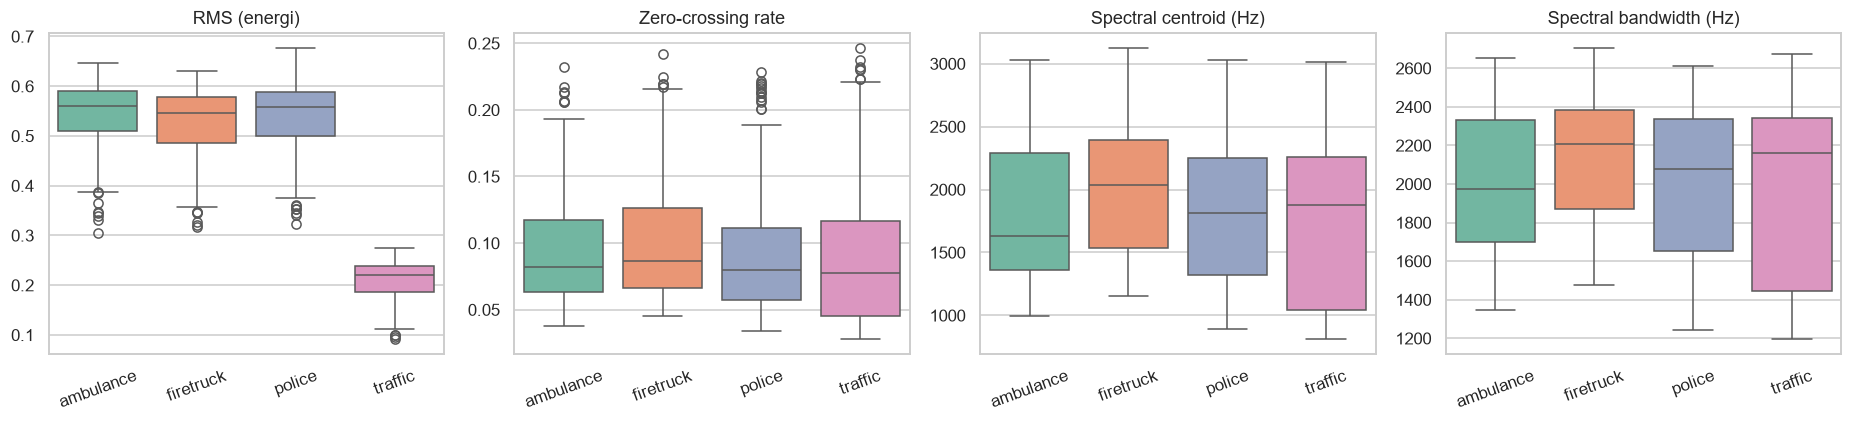

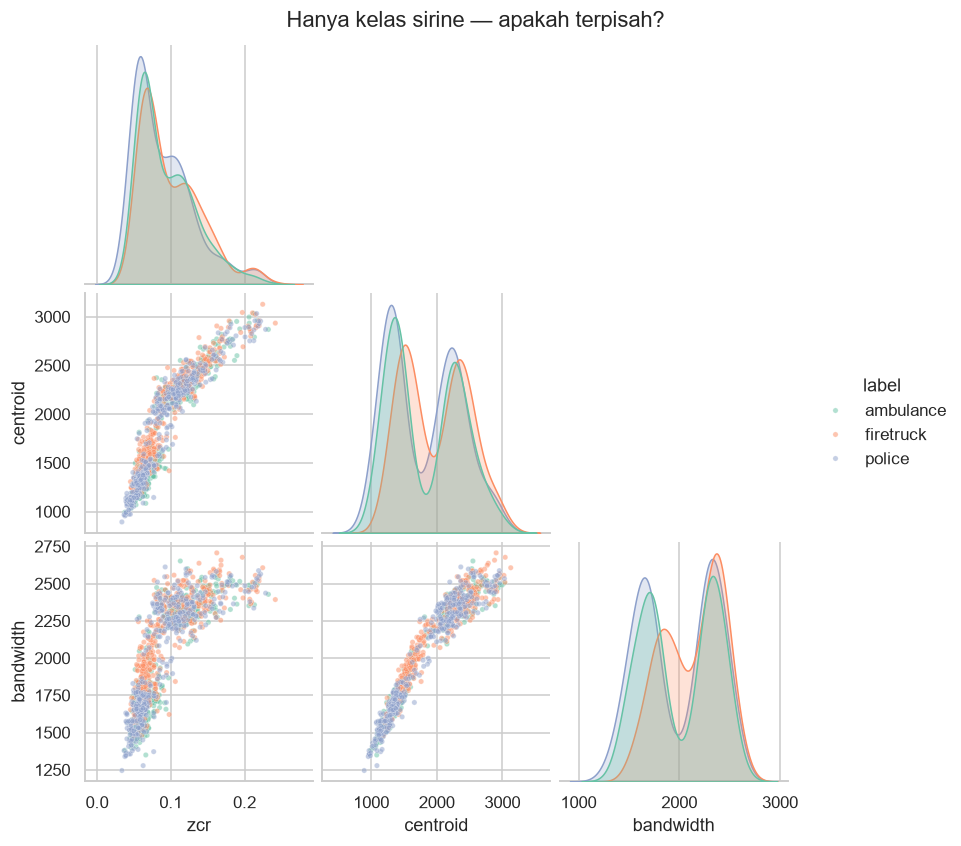

In [12]:
FEATURES = {
    "rms": "RMS (energi)",
    "zcr": "Zero-crossing rate",
    "centroid": "Spectral centroid (Hz)",
    "bandwidth": "Spectral bandwidth (Hz)",
}

fig, axes = plt.subplots(1, 4, figsize=(17, 4))
for ax, (col, title) in zip(axes, FEATURES.items()):
    sns.boxplot(data=df, x="label", y=col, order=CLASSES,
                palette=PALETTE, hue="label", legend=False, ax=ax)
    ax.set(title=title, xlabel="", ylabel="")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(FIG_DIR / "acoustic_features.png", bbox_inches="tight")
plt.show()

# pairplot khusus 3 kelas sirine — lihat apakah ada yang memisahkan mereka
sirens = df[df.label != "traffic"]
sns.pairplot(sirens[["label", "zcr", "centroid", "bandwidth"]],
             hue="label", palette=PALETTE, corner=True,
             plot_kws={"s": 12, "alpha": 0.5})
plt.suptitle("Hanya kelas sirine — apakah terpisah?", y=1.02)
plt.savefig(FIG_DIR / "siren_separability.png", bbox_inches="tight")
plt.show()


ambulance:   0%|          | 0/100 [00:00<?, ?it/s]


ambulance:  20%|██        | 20/100 [00:00<00:00, 197.25it/s]


ambulance:  40%|████      | 40/100 [00:00<00:00, 195.05it/s]


ambulance:  60%|██████    | 60/100 [00:00<00:00, 194.89it/s]


ambulance:  81%|████████  | 81/100 [00:00<00:00, 197.16it/s]

...


traffic:   0%|          | 0/100 [00:00<?, ?it/s]


traffic:  21%|██        | 21/100 [00:00<00:00, 202.73it/s]


traffic:  42%|████▏     | 42/100 [00:00<00:00, 198.59it/s]


traffic:  62%|██████▏   | 62/100 [00:00<00:00, 198.60it/s]


traffic:  82%|████████▏ | 82/100 [00:00<00:00, 196.89it/s]

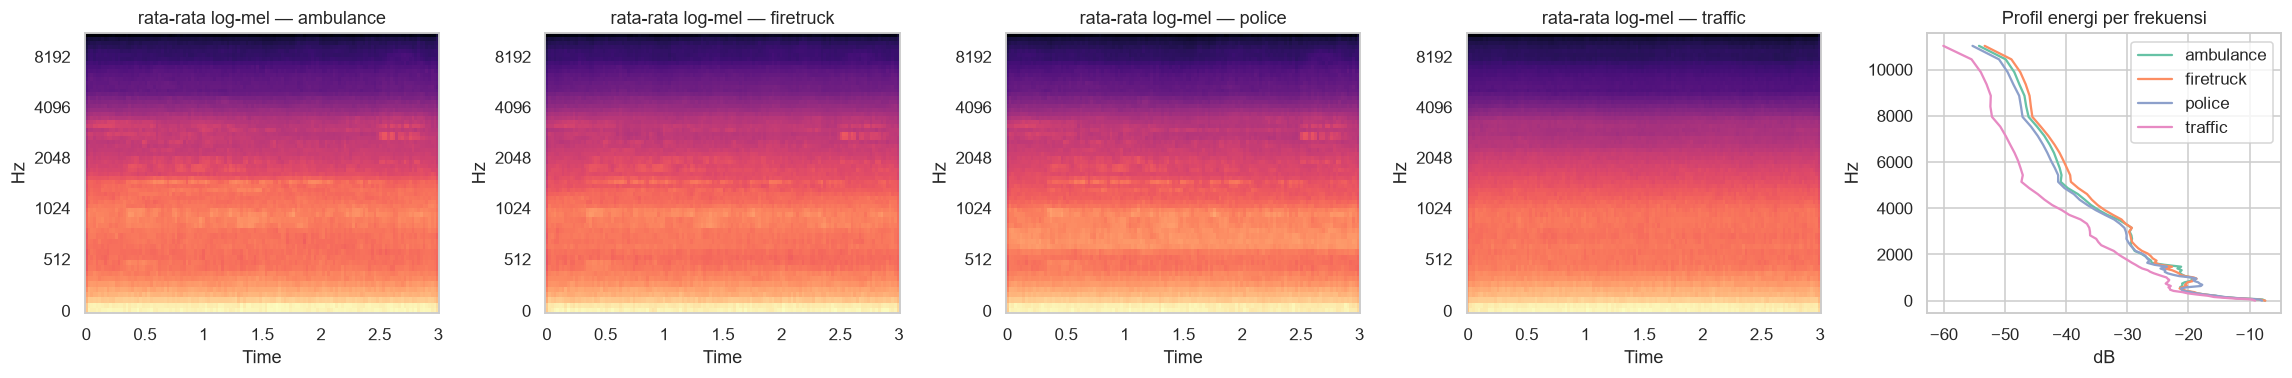

In [13]:
# --- sidik jari frekuensi per kelas ---
MAX_PER_CLASS = 100          # naikkan kalau mau lebih presisi (lebih lambat)

profiles = {}
for cls in CLASSES:
    paths = df[df.label == cls].path.sample(
        min(MAX_PER_CLASS, (df.label == cls).sum()), random_state=42)
    spec = np.stack([logmel(load_audio(p))
                     for p in tqdm(paths, desc=cls, leave=False)])
    profiles[cls] = spec.mean(axis=0)

mel_hz = librosa.mel_frequencies(n_mels=N_MELS, fmin=0, fmax=SR // 2)

fig, axes = plt.subplots(1, len(CLASSES) + 1,
                         figsize=(4.2 * (len(CLASSES) + 1), 3.6))
for ax, cls in zip(axes, CLASSES):
    librosa.display.specshow(profiles[cls], sr=SR, hop_length=HOP,
                             x_axis="time", y_axis="mel", ax=ax)
    ax.set_title(f"rata-rata log-mel — {cls}")

for cls in CLASSES:
    axes[-1].plot(profiles[cls].mean(axis=1), mel_hz,
                  label=cls, color=PALETTE[cls])
axes[-1].set(title="Profil energi per frekuensi", xlabel="dB", ylabel="Hz")
axes[-1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "frequency_profile.png", bbox_inches="tight")
plt.show()

---
## 7 · Ringkasan

In [14]:
n_sr = df.sample_rate.nunique()
n_stereo = int((df.channels == 2).sum())
n_off_dur = len(df[(df.duration - DURATION).abs() > 0.05])

print("=" * 62)
print("RINGKASAN EDA — DATASET 2")
print("=" * 62)
print(f"Total file          : {len(df)}")
print(f"Total source unik   : {df.source_id.nunique()}")
print(f"Kelas               : {', '.join(CLASSES)}")
print(f"File per kelas      : {counts.to_dict()}")
print(f"Source per kelas    : {src_counts.to_dict()}")
print(f"File corrupt        : {len(corrupt)}")
print(f"File duplikat       : {n_dup}")
print(f"Sample rate         : {sorted(df.sample_rate.dropna().unique())}")
print(f"Stereo              : {n_stereo}/{len(df)}")
print(f"Durasi              : {df.duration.min():.2f}–{df.duration.max():.2f} s")
print("-" * 62)
print("IMPLIKASI PREPROCESSING")
print(f"  • resample ke {SR} Hz  → {'WAJIB' if n_sr > 1 else 'ya (turunkan dari 44.1k)'}")
print(f"  • konversi mono       → {'WAJIB' if n_stereo else 'tidak perlu'}")
print(f"  • pad/crop ke {DURATION}s   → "
      f"{'perlu' if n_off_dur else 'tidak perlu (durasi sudah seragam)'}")
print("  • peak normalize      → ya")
print("-" * 62)
print("IMPLIKASI SPLIT  ← yang paling menentukan")
print(f"  • {len(df)} file hanya berasal dari {df.source_id.nunique()} rekaman unik")
print(f"  • random split membocorkan {leak_random} source ke train & test")
print("  • WAJIB pakai GroupShuffleSplit(groups=source_id)")
print("  • setelah split, assert irisan source_id antar split == kosong")
print("=" * 62)

out = ROOT / "ml" / "eda_dataset2.csv"
out.parent.mkdir(parents=True, exist_ok=True)
df.drop(columns=["path"]).to_csv(out, index=False)
print(f"\ninventaris tersimpan → {out}")

RINGKASAN EDA — DATASET 2
Total file          : 1675
Total source unik   : 1048
Kelas               : ambulance, firetruck, police, traffic
File per kelas      : {'ambulance': 400, 'firetruck': 400, 'police': 454, 'traffic': 421}
Source per kelas    : {'ambulance': 200, 'firetruck': 200, 'police': 227, 'traffic': 421}
File corrupt        : 0
File duplikat       : 0
Sample rate         : [np.int64(44100)]
Stereo              : 1675/1675
Durasi              : 3.00–3.02 s
--------------------------------------------------------------
IMPLIKASI PREPROCESSING
  • resample ke 22050 Hz  → ya (turunkan dari 44.1k)
  • konversi mono       → WAJIB
  • pad/crop ke 3.0s   → tidak perlu (durasi sudah seragam)
  • peak normalize      → ya
--------------------------------------------------------------
IMPLIKASI SPLIT  ← yang paling menentukan
  • 1675 file hanya berasal dari 1048 rekaman unik
  • random split membocorkan 164 source ke train & test
  • WAJIB pakai GroupShuffleSplit(groups=source_id)
 

---

**Selanjutnya:** `03_baseline_model.ipynb` memakai temuan di sini — manifest dengan `source_id`,
group split, log-mel 64 mel, CNN 2D.